<a href="https://colab.research.google.com/github/IJackson00/Week2Assignment2LogReg/blob/main/MAI_540_Module_3_In_Class_Activity_1_assignment1_week3_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


 TRAINING DATASET: HEART DISEASE (LINEAR/STRUCTURED)


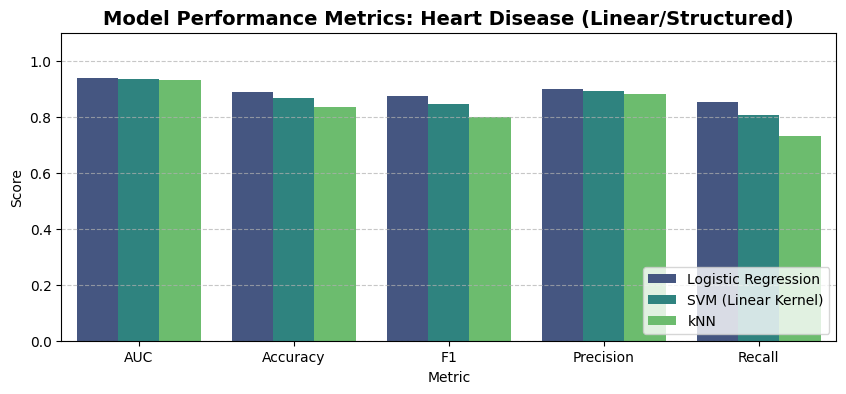

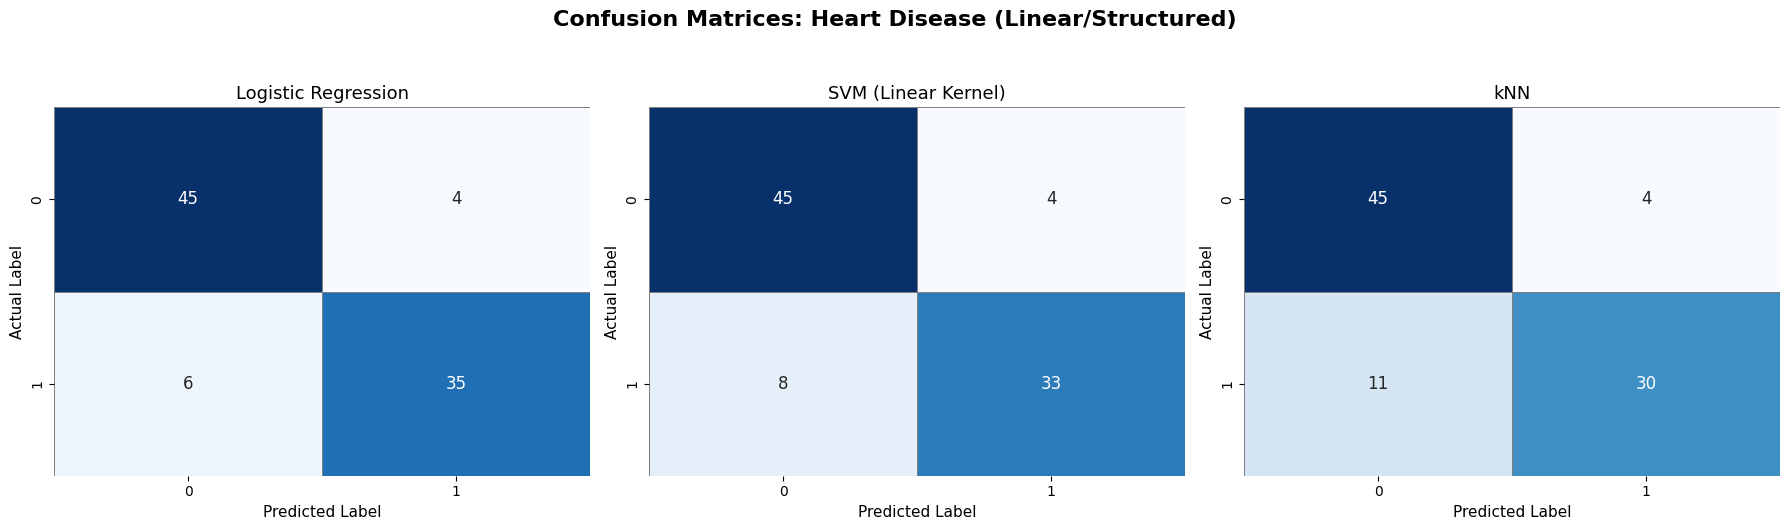


 TRAINING DATASET: SYNTHETIC BULLSEYE (HIGHLY NON-LINEAR)


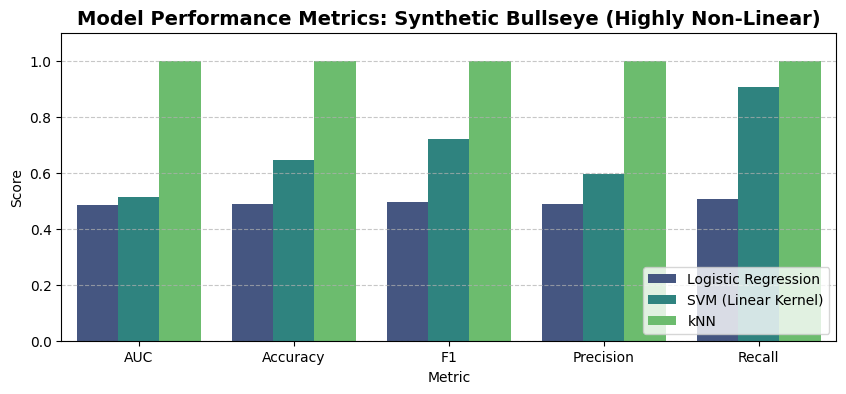

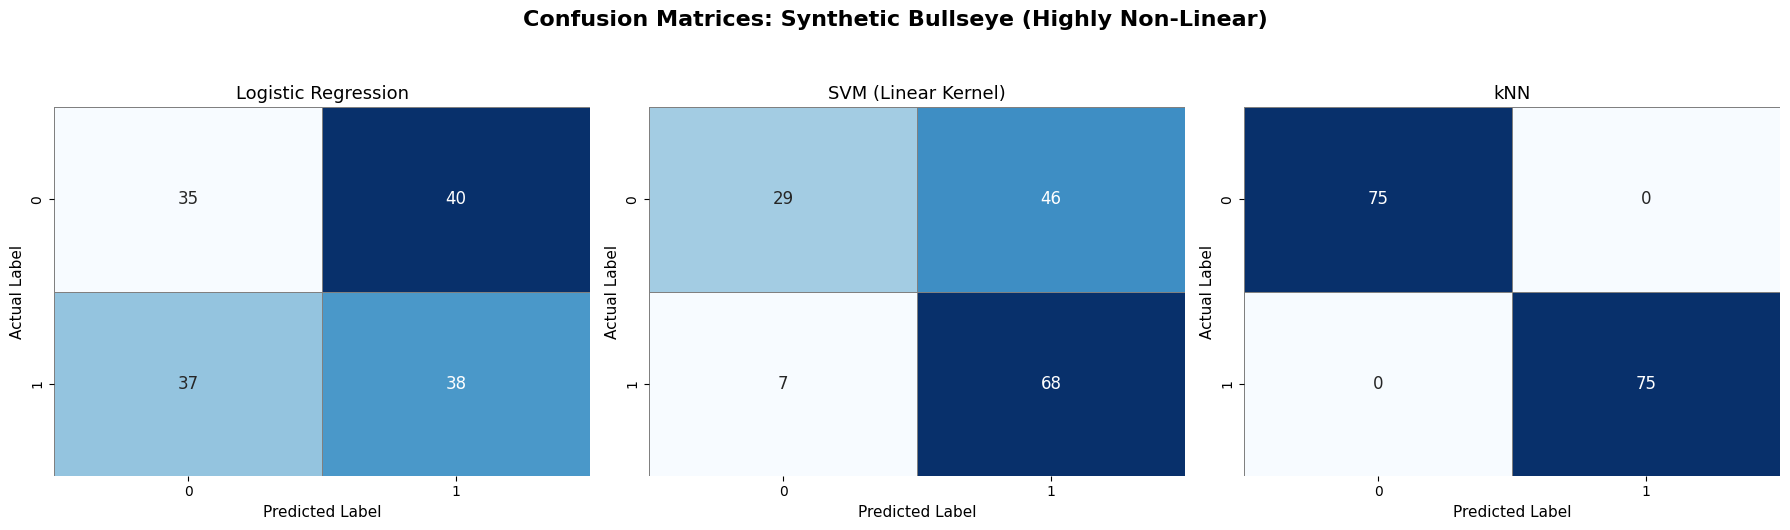


 TRAINING DATASET: IONOSPHERE RADAR (COMPLEX/HIGH-DIMENSIONAL)


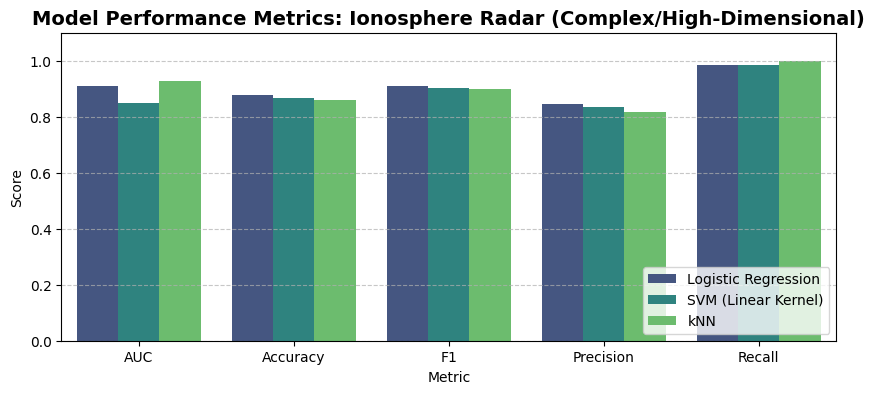

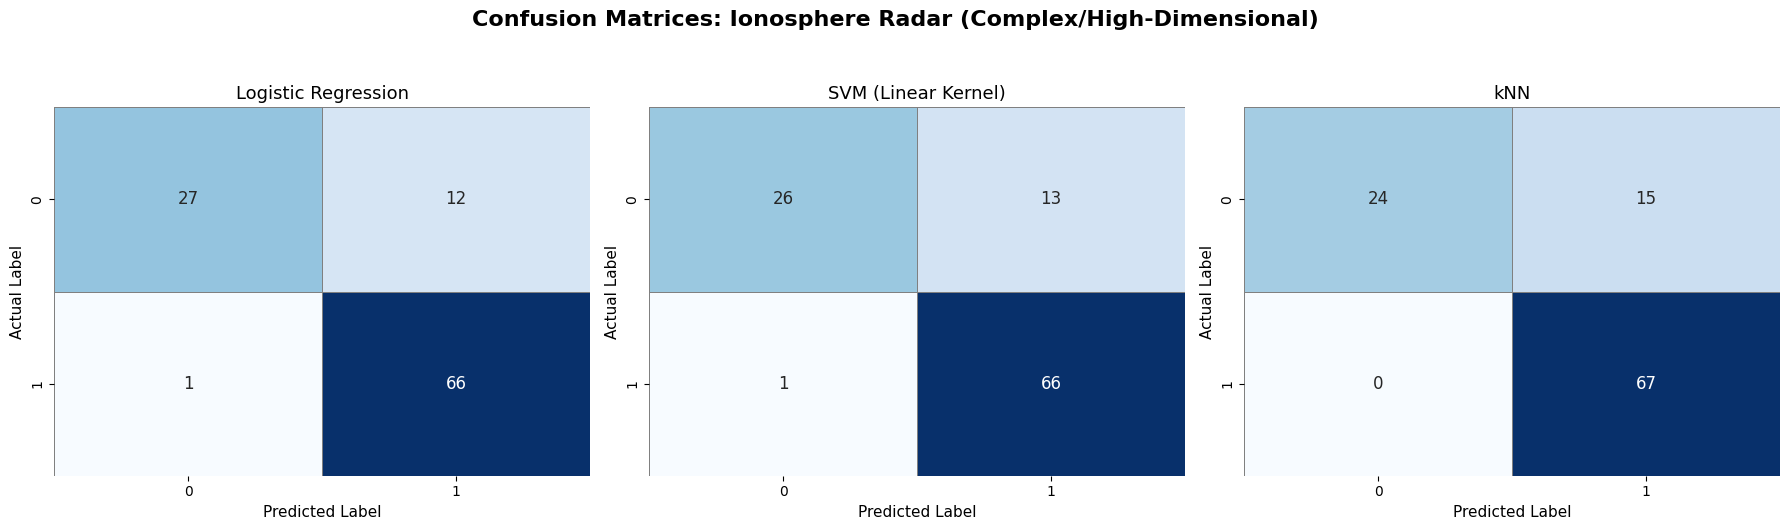


 TRAINING DATASET: GLASS IDENTIFICATION (MULTICLASS/CLUSTERED)


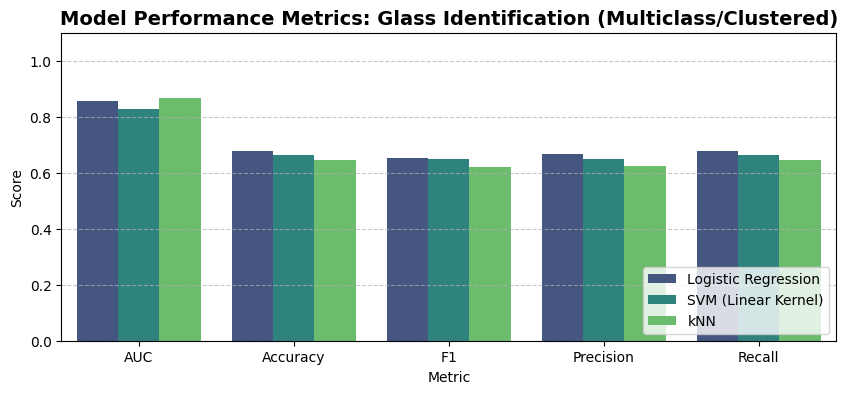

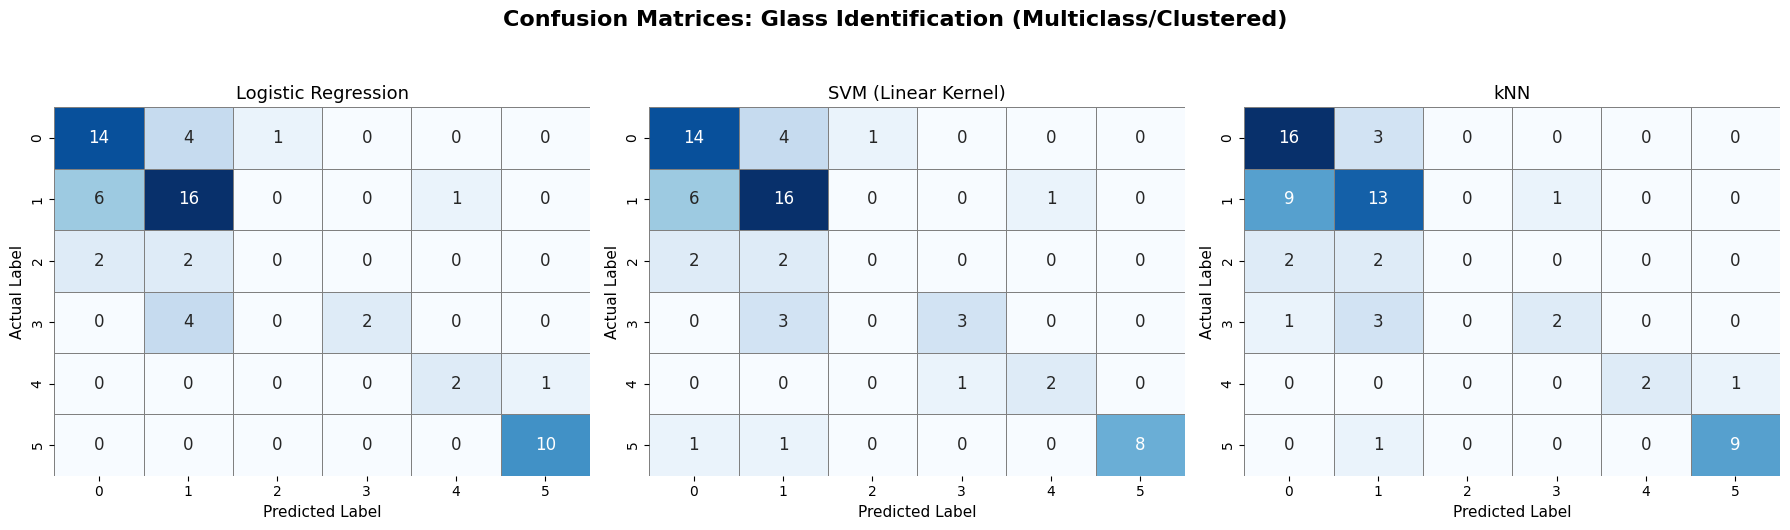


 EDGE DEPLOYMENT CHALLENGE: INFERENCE SPEED TEST
Simulating real-time sensor processing (10,000 predictions on a single data point)...

Logistic Regression       | Total Time: 18.4869 seconds
SVM (Linear Kernel)       | Total Time: 11.1293 seconds
kNN (k=5)                 | Total Time: 26.9182 seconds

 FINAL CONCEPT CHECK
Test your understanding of model selection and hardware constraints.

1. Look at the confusion matrices for the Heart Disease dataset. If deploying in a hospital, which error is the most dangerous, and which metric captures it?
A) False Positives; measured by Precision.
B) False Negatives; measured by Recall.
C) True Positives; measured by Accuracy.
D) True Negatives; measured by F1 Score.


In [ ]:
import pandas as pd
import numpy as np
import warnings
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_circles
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# Ignore warnings for a cleaner output during class
warnings.filterwarnings('ignore')

# ==========================================
# SECTION 1: THE VISUAL EVALUATION PIPELINE
# ==========================================
def evaluate_dataset(dataset_name, X, y):
    """
    Scales data, splits it, trains 3 models, and plots the metrics and confusion matrices.
    """
    # Encode labels
    y_encoded = LabelEncoder().fit_transform(y)
    is_multiclass = len(np.unique(y_encoded)) > 2
    avg_method = 'weighted' if is_multiclass else 'binary'

    # Scale and split
    X_scaled = StandardScaler().fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.30, random_state=42)

    # Initialize models
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "SVM (Linear Kernel)": SVC(kernel='linear', probability=True, random_state=42),
        "kNN": KNeighborsClassifier(n_neighbors=5)
    }

    metrics_list = []
    cms = {}

    print(f"\n{'='*80}")
    print(f" TRAINING DATASET: {dataset_name.upper()}")
    print(f"{'='*80}")

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)

        # Calculate AUC safely
        try:
            if is_multiclass:
                auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
            else:
                auc = roc_auc_score(y_test, y_prob[:, 1])
        except ValueError:
            auc = np.nan

        # Calculate standard metrics
        ca = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average=avg_method)
        prec = precision_score(y_test, y_pred, average=avg_method, zero_division=0)
        rec = recall_score(y_test, y_pred, average=avg_method)

        metrics_list.append({"Model": name, "AUC": auc, "Accuracy": ca, "F1": f1, "Precision": prec, "Recall": rec})
        cms[name] = confusion_matrix(y_test, y_pred)

    # --- PLOT 1: Metric Comparison Bar Chart ---
    df_metrics = pd.DataFrame(metrics_list)
    df_melted = df_metrics.melt(id_vars="Model", var_name="Metric", value_name="Score")

    plt.figure(figsize=(10, 4))
    sns.barplot(data=df_melted, x="Metric", y="Score", hue="Model", palette="viridis")
    plt.title(f"Model Performance Metrics: {dataset_name}", fontsize=14, fontweight='bold')
    plt.ylim(0, 1.1)
    plt.legend(loc='lower right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # --- PLOT 2: Side-by-Side Confusion Matrices ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Confusion Matrices: {dataset_name}", fontsize=16, fontweight='bold', y=1.05)

    for ax, (name, cm) in zip(axes, cms.items()):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                    annot_kws={"size": 12}, linewidths=.5, linecolor='gray')
        ax.set_title(name, fontsize=13)
        ax.set_xlabel('Predicted Label', fontsize=11)
        ax.set_ylabel('Actual Label', fontsize=11)

    plt.tight_layout()
    plt.show()


# ==========================================
# SECTION 2: LOAD & EVALUATE DATASETS
# ==========================================

# --- Dataset A: Heart Disease (Linear / Medical) ---
url_heart = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
df_heart = pd.read_csv(url_heart, header=None, na_values="?").dropna()
X_heart = df_heart.iloc[:, :-1]
y_heart = (df_heart.iloc[:, -1] > 0).astype(int)
evaluate_dataset("Heart Disease (Linear/Structured)", X_heart, y_heart)

# --- Dataset B: Synthetic Bullseye (Non-Linear) ---
X_circle, y_circle = make_circles(n_samples=500, factor=0.3, noise=0.1, random_state=42)
evaluate_dataset("Synthetic Bullseye (Highly Non-Linear)", X_circle, y_circle)

# --- Dataset C: Ionosphere (Complex / High-Dimensional) ---
url_iono = "https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data"
df_iono = pd.read_csv(url_iono, header=None)
X_iono = df_iono.iloc[:, :-1]
y_iono = df_iono.iloc[:, -1]
evaluate_dataset("Ionosphere Radar (Complex/High-Dimensional)", X_iono, y_iono)

# --- Dataset D: Glass Identification (Clustered / Spatial / Multiclass) ---
url_glass = "https://archive.ics.uci.edu/ml/machine-learning-databases/glass/glass.data"
df_glass = pd.read_csv(url_glass, header=None)
X_glass = df_glass.iloc[:, 1:-1]
y_glass = df_glass.iloc[:, -1]
evaluate_dataset("Glass Identification (Multiclass/Clustered)", X_glass, y_glass)


# ==========================================
# SECTION 3: EDGE DEPLOYMENT SPEED TEST
# ==========================================
print(f"\n{'='*80}")
print(" EDGE DEPLOYMENT CHALLENGE: INFERENCE SPEED TEST")
print(f"{'='*80}")
print("Simulating real-time sensor processing (10,000 predictions on a single data point)...\n")

X_train_hd, X_test_hd, y_train_hd, y_test_hd = train_test_split(X_heart, y_heart, test_size=0.30, random_state=42)

speed_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000).fit(X_train_hd, y_train_hd),
    "SVM (Linear Kernel)": SVC().fit(X_train_hd, y_train_hd),
    "kNN (k=5)": KNeighborsClassifier(n_neighbors=5).fit(X_train_hd, y_train_hd)
}

# Grab exactly one patient's data to simulate a live sensor reading
single_reading = X_test_hd.iloc[[0]]

for name, model in speed_models.items():
    start_time = time.time()
    for _ in range(10000):
        model.predict(single_reading)
    total_time = time.time() - start_time
    print(f"{name:<25} | Total Time: {total_time:.4f} seconds")


# ==========================================
# SECTION 4: FINAL CONCEPT CHECK (QUIZ)
# ==========================================
print(f"\n{'='*80}")
print(" FINAL CONCEPT CHECK")
print(f"{'='*80}")
print("Test your understanding of model selection and hardware constraints.\n")

questions = [
    {
        "prompt": "1. Look at the confusion matrices for the Heart Disease dataset. If deploying in a hospital, which error is the most dangerous, and which metric captures it?",
        "options": [
            "A) False Positives; measured by Precision.",
            "B) False Negatives; measured by Recall.",
            "C) True Positives; measured by Accuracy.",
            "D) True Negatives; measured by F1 Score."
        ],
        "answer": "B",
        "explanation": "Correct! A False Negative tells a sick patient they are healthy. Recall measures how well the model finds all the actual positive (sick) cases."
    },
    {
        "prompt": "\n2. Based on the Inference Speed Test, why is kNN a poor choice for real-time sensor processing on a resource-constrained microcontroller?",
        "options": [
            "A) It requires a GPU to calculate the distances.",
            "B) It relies on a linear kernel which takes too long.",
            "C) It stores the entire training dataset in memory and calculates distances for every new prediction.",
            "D) It converts the data into higher dimensions, draining the battery."
        ],
        "answer": "C",
        "explanation": "Correct! kNN does its heavy lifting (and memory usage) during inference. Edge devices lack the RAM and CPU to do this efficiently."
    },
    {
        "prompt": "\n3. If you changed the SVM parameter to `kernel='linear'` on the Synthetic Bullseye dataset, accuracy would drop to 50%. Why?",
        "options": [
            "A) The linear kernel forces the SVM to draw a straight line, which cannot separate a circle.",
            "B) The linear kernel is only designed for multiclass problems.",
            "C) The learning rate is too high for a linear kernel.",
            "D) The linear kernel removes the standard scaler."
        ],
        "answer": "A",
        "explanation": "Correct! An RBF kernel mathematically projects the data so a flat plane can slice the bullseye. A linear kernel just tries to draw a straight line through the 2D plane, failing completely."
    }
]

score = 0

for q in questions:
    print(q["prompt"])
    for option in q["options"]:
        print(option)

    student_answer = input("Enter your answer (A/B/C/D): ").strip().upper()

    if student_answer == q["answer"]:
        print("\n✅ Correct!")
        print(f"Explanation: {q['explanation']}")
        score += 1
    else:
        print(f"\n❌ Incorrect. The correct answer was {q['answer']}.")
        print(f"Explanation: {q['explanation']}")
    print("-" * 80)

print(f"\nQuiz Complete! You scored {score} out of {len(questions)}.")
if score == 3:
    print("Excellent work! You are ready to deploy these models to edge hardware.")
else:
    print("Review the visual metrics and speed tests above, then try again!")

Logistic Regression vs. Support Vector Machines: Applications and Comparisons
Heart Disease (Linear / Structured)
The Heart Disease (Linear / Structured) medical data is organized (age, cholesterol, blood pressure, etc.) can be separated through boolean logic, i.e., to answer whether a disease exists, “true or false,” or “disease” vs “no disease.” This also means that it is “linear,” able to be represented according to a logistic regression and a linear support vector machine (SVM).  Another method utilized is the K-Nearest Neighbors (KNN), a simple, non-parametric, supervised machine learning algorithm used for classification and regression (ChatGPT). The F1 score is a crucial machine learning evaluation metric for classification models, representing the harmonic mean of precision and recall, more specifically defined as 2(Precision * Recall / Precision + Recall) (ChatGPT).
Model Performance Metrics Heart Disease (Linear / Structured)
The Python programming language is used within Google Colab. A change from the "SVM (RBF Kernel)": SVC(probability=True, random_state=42),” to the "SVM (Linear Kernel)": SVC(kernel='linear', probability=True, random_state=42)” yields alterations in the data as depicted by the charts. According to the aforementioned information, the categories Area Under the Curve (AUC), Accuracy, (F1), Precision (ratio of true positives to all predicted positives), and Recall / Sensitivity (ratio of true positives to all actual positives), decreased in logistic regression, SVM, and kNN depicted on the bar graph. The Confusion Matrices: Heart Disease (Linear/ Structured) depicts changes in the “Actual Label” versus the “Predicted Label.” The Synthetic Bullseye (Highly Non-Linear) bar graph depicts a significant decrease in SVM (Linear Kernel) while roughly maintaining the kNN and Logistic Regression. The Performance Metrics: Ionosphere Radar (Complex / High-Dimensional) decreases in all categories except “Recall.” The Performance Metrics: Glass Identification (Multiclass / Clustered) bar graph depicts slight increases in all categories with minor SVM (RBF Kernel) changes in “Actual Label.”